# Credit Card Fraud — Extreme Class Imbalance

Real Kaggle competition data (see `data/credit_card_fraud/SOURCE.md`): a
**stratified 14,992-row subsample** of the 284,807-row original — all 492
real fraud transactions plus 14,500 randomly sampled non-fraud, so the
positive rate here is **~3.28%**, deliberately *enriched* from the real
**0.173%** so the notebook runs fast. **This is disclosed here and in
`SOURCE.md` — do not read the metrics below as representative of the true
0.17%-imbalance production problem**; treat this as a "hard but tractable"
teaching version of the real extreme-imbalance dataset. Features `V1..V28`
are PCA components (already anonymized/decorrelated by the dataset's
authors), plus `Time` and `Amount`.

This notebook demonstrates:
- Full EDA on a naturally near-decorrelated PCA feature set.
- A leakage-safe pipeline: `StandardScaler` on `Time`/`Amount` (the two
  non-PCA columns) -> **both** `Oversampling` (SMOTE) and `Undersampling`
  compared, fit on the training split only.
- Evaluation focused on **precision/recall/PR-AUC** (the right metrics for
  rare-event detection), not accuracy or even ROC-AUC alone — in fraud
  detection, PR-AUC is the standard because the positive class is what
  matters.

Polars + numpy only — no pandas.

In [1]:
import numpy as np
import polars as pl

from skyulf import EDAAnalyzer, EDAVisualizer, SkyulfPipeline

train = pl.read_csv("data/credit_card_fraud/creditcard_sample.csv", infer_schema_length=None)
print(train.shape)
print(f"Class positive rate in this sample: {train['Class'].mean():.4%}  (real dataset: 0.173%)")
train.head(3)

(14992, 31)
Class positive rate in this sample: 3.2818%  (real dataset: 0.173%)


Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64
60800.0,-2.54408,1.640947,1.492674,-0.830515,-0.500835,0.082449,1.163972,-0.364459,2.467345,2.664449,0.896485,0.481584,-0.900995,-1.676727,-1.916666,-0.529886,-0.659373,-0.22707,-0.094586,0.988077,-0.604333,0.157442,-0.174914,0.349782,0.369262,0.27021,0.330708,-0.544469,68.58,0
60600.0,-1.121487,-0.454337,1.856982,-0.245145,0.667138,0.236111,-0.131605,0.433688,0.265283,-0.877745,0.43204,1.124152,-0.107358,-0.450727,-2.01014,-0.256874,-0.136441,-0.407075,-0.305023,0.1142,0.05875,0.127293,-0.033639,-0.246493,0.289947,0.400303,-0.045205,0.003302,49.93,0
97563.0,2.02454,-0.238464,-1.054008,0.309823,-0.003132,-0.416991,-0.223361,-0.157146,2.25287,-0.395365,1.278936,-1.576324,1.102684,1.743476,-1.764898,-0.432407,0.395947,0.390485,0.413947,-0.303069,-0.040303,0.422396,0.006178,-0.404632,0.163255,0.1633099,-0.056197,-0.083944,3.3,0


## 1. Full EDA

In [2]:
profile = EDAAnalyzer(train).analyze(target_col="Class")

print(f"Rows: {profile.row_count}  Columns: {len(profile.columns)}")
print(f"Missing cells: {profile.missing_cells_percentage:.2f}%")
print(f"Alerts ({len(profile.alerts)} total), first 8:")
for a in profile.alerts[:8]:
    print(" -", a.message)

calculate_correlations: 30 numeric columns exceeds the 20-column cap; truncating to the first 20 by column order (not variance or relevance) and dropping ['V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount'] from the correlation matrix.
calculate_correlations: 31 numeric columns exceeds the 20-column cap; truncating to the first 20 by column order (not variance or relevance) and dropping ['V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class'] from the correlation matrix.


Rows: 14992  Columns: 31
Missing cells: 0.00%
Alerts (32 total), first 8:
 - Column 'V1' contains significant outliers.
 - Column 'V2' contains significant outliers.
 - Column 'V3' contains significant outliers.
 - Column 'V4' contains significant outliers.
 - Column 'V5' contains significant outliers.
 - Column 'V6' contains significant outliers.
 - Column 'V7' contains significant outliers.
 - Column 'V8' contains significant outliers.


In [3]:
print("Target-association recommendations (first 6):")
for r in profile.recommendations[:6]:
    print(" -", r.message if hasattr(r, "message") else r)

Target-association recommendations (first 6):
 - column='V1' action='Transform' reason='High skewness (-4.42)' suggestion="Apply Log or Box-Cox transformation to 'V1'."
 - column='V3' action='Transform' reason='High skewness (-5.38)' suggestion="Apply Log or Box-Cox transformation to 'V3'."
 - column='V4' action='Transform' reason='High skewness (1.60)' suggestion="Apply Log or Box-Cox transformation to 'V4'."
 - column='V5' action='Transform' reason='High skewness (-4.10)' suggestion="Apply Log or Box-Cox transformation to 'V5'."
 - column='V7' action='Transform' reason='High skewness (-6.20)' suggestion="Apply Log or Box-Cox transformation to 'V7'."
 - column='V8' action='Transform' reason='High skewness (-7.89)' suggestion="Apply Log or Box-Cox transformation to 'V8'."


In [4]:
EDAVisualizer(profile, train).summary()

╭────────────────────╮
│ Skyulf EDA Summary │
╰────────────────────╯

1. Data Quality

┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ Metric         ┃ Value          ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ Rows           │ 14992          │
│ Columns        │ 31             │
│ Missing Cells  │ 0.0%           │
│ Duplicate Rows │ 44             │
│ Target Column  │ Class          │
│ Task Type      │ Classification │
└────────────────┴────────────────┘

2. Numeric Statistics

┏━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┓
┃ Column ┃     Mean ┃      Std ┃    Min ┃       Max ┃  Skew ┃   Kurt ┃ Normality ┃
┡━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━┩
│ Time   │ 94518.10 │ 47745.58 │  34.00 │ 172777.00 │ -0.03 │  -1.30 │    No     │
│ V1     │    -0.15 │     2.40 │ -31.32 │      2.40 │ -4.42 │  37.16 │    No     │
│ V2     │     0.14 │     1.85 │ -38.69 │     22.06 │ -1.07 │  54.91 │    No     │
│ V3     │    -0.22 │     2.28 │ -31.10 │      3.82 │ -5.38 │  50.64 │    No     │
│ V4     │     0.13 │     1.68 │  -4.94 │     13.14 │  1.60 │   6.58 │    No     │
│ V5     │    -0.10 │     1.75 │ -42.15 │     24.66 │ -4.10 │  60.92 │    No     │
│ V6     │    -0.04 │     1.36 │ -16.06 │     22.53 │  1.48 │  12.53 │    No     │
│ V7     │    -0.16 │     1.99 │ -43.56 │     36.68 │ -6.20 │ 103.88 │    No     │
│ V8     │     0.02 │     1.65 │ -41.04 │     20.01 │ -7.89 │ 195.17 │    No     │
│ V9     │    -0.07 │     1.25 │ -13.43 │      9.23 │ -0.67 │   8.65 │    No     │
│ V10    │    -0.17 │     1.71 │ -24.59 │     13.16 │ -3.83 │  42.46 │    No     │
│ V11    │     0.11 │     1.29 │  -3.42 │     12.02 │  2.00 │  10.62 │    No     │
│ V12    │    -0.19 │     1.67 │ -18.68 │      3.60 │ -4.86 │  35.31 │    No     │
│ V13    │     0.00 │     0.99 │  -3.47 │      3.67 │  0.06 │   0.10 │    Yes    │
│ V14    │    -0.21 │     1.70 │ -19.21 │      5.46 │ -4.62 │  30.78 │    No     │
│ V15    │     0.00 │     0.92 │  -4.50 │      4.08 │ -0.33 │   0.23 │    No     │
│ V16    │    -0.12 │     1.31 │ -14.13 │      6.10 │ -4.01 │  28.48 │    No     │
│ V17    │    -0.22 │     1.87 │ -25.16 │      6.98 │ -6.72 │  61.19 │    No     │
│ V18    │    -0.07 │     1.04 │  -9.50 │      4.08 │ -2.14 │  13.82 │    No     │
│ V19    │     0.02 │     0.86 │  -3.89 │      5.23 │  0.30 │   2.17 │    No     │
│ V20    │     0.01 │     0.79 │ -20.21 │     17.89 │ -1.58 │ 130.99 │    No     │
│ V21    │     0.02 │     1.00 │ -22.80 │     27.20 │  7.94 │ 301.01 │    No     │
│ V22    │    -0.01 │     0.76 │  -8.89 │      8.36 │ -0.52 │  10.50 │    No     │
│ V23    │    -0.00 │     0.65 │ -19.25 │     19.23 │ -0.49 │ 273.07 │    No     │
│ V24    │     0.00 │     0.61 │  -2.76 │      4.01 │ -0.60 │   0.52 │    No     │
│ V25    │    -0.00 │     0.53 │  -4.78 │      5.52 │ -0.32 │   3.50 │    No     │
│ V26    │    -0.00 │     0.48 │  -1.52 │      3.16 │  0.55 │   0.92 │    No     │
│ V27    │     0.01 │     0.49 │  -8.57 │     11.14 │ -1.84 │  84.69 │    No     │
│ V28    │     0.00 │     0.36 │  -9.62 │     15.62 │  8.19 │ 531.19 │    No     │
│ Amount │    87.53 │   234.85 │   0.00 │   8182.70 │ 11.28 │ 241.55 │    No     │
└────────┴──────────┴──────────┴────────┴───────────┴───────┴────────┴───────────┘

...

• Column 'V28' contains significant outliers.

• Column 'Amount' contains significant outliers.

• Column 'V2' has high VIF (6.6).

• Column 'V7' has high VIF (8.0).

• Column 'Amount' has very high VIF (13.0). Consider removing it.

/Users/BH7043/Skyulf/.venv/lib/python3.12/site-packages/pandas/plotting/_matplotlib/misc.py:96: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(


Displaying plots...


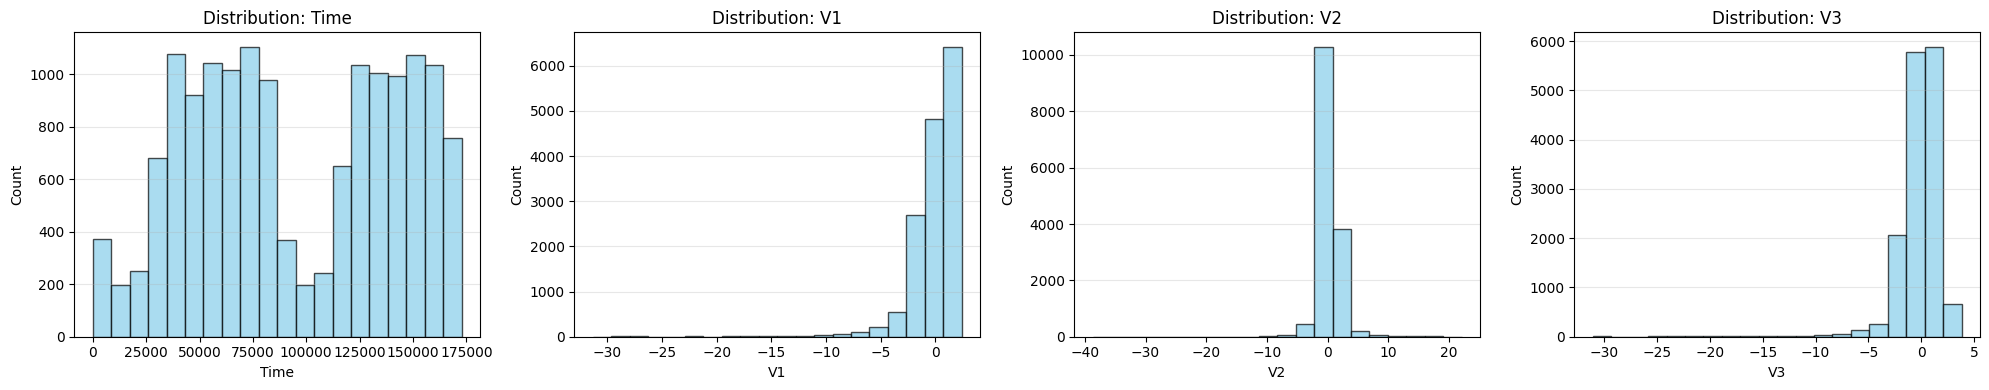

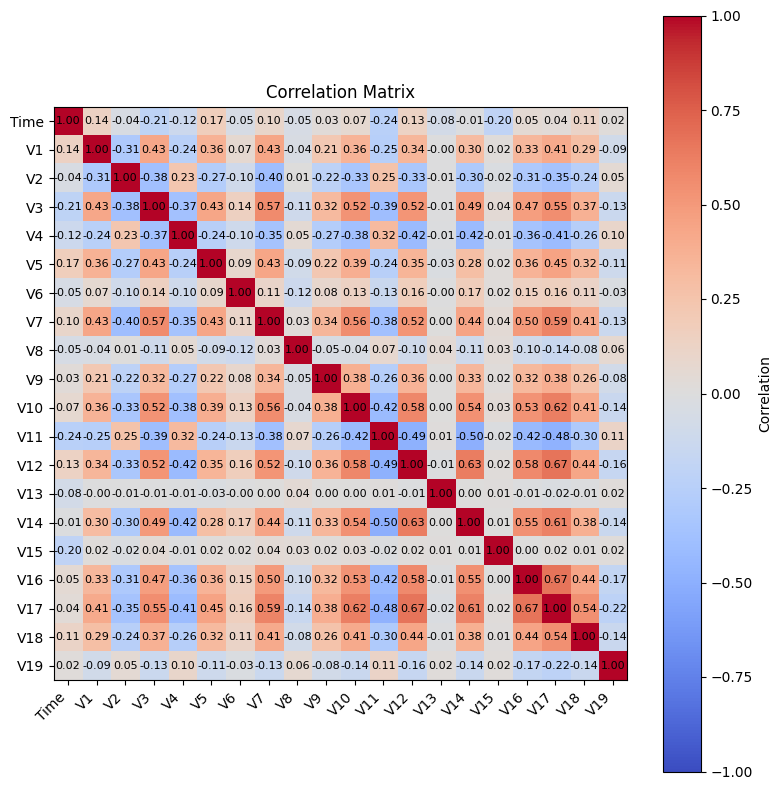

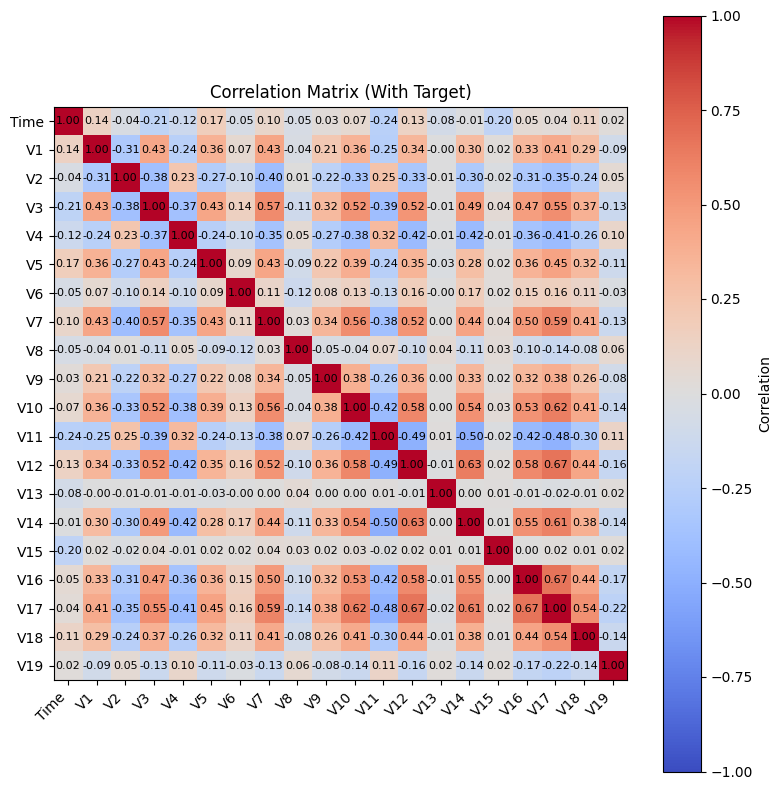

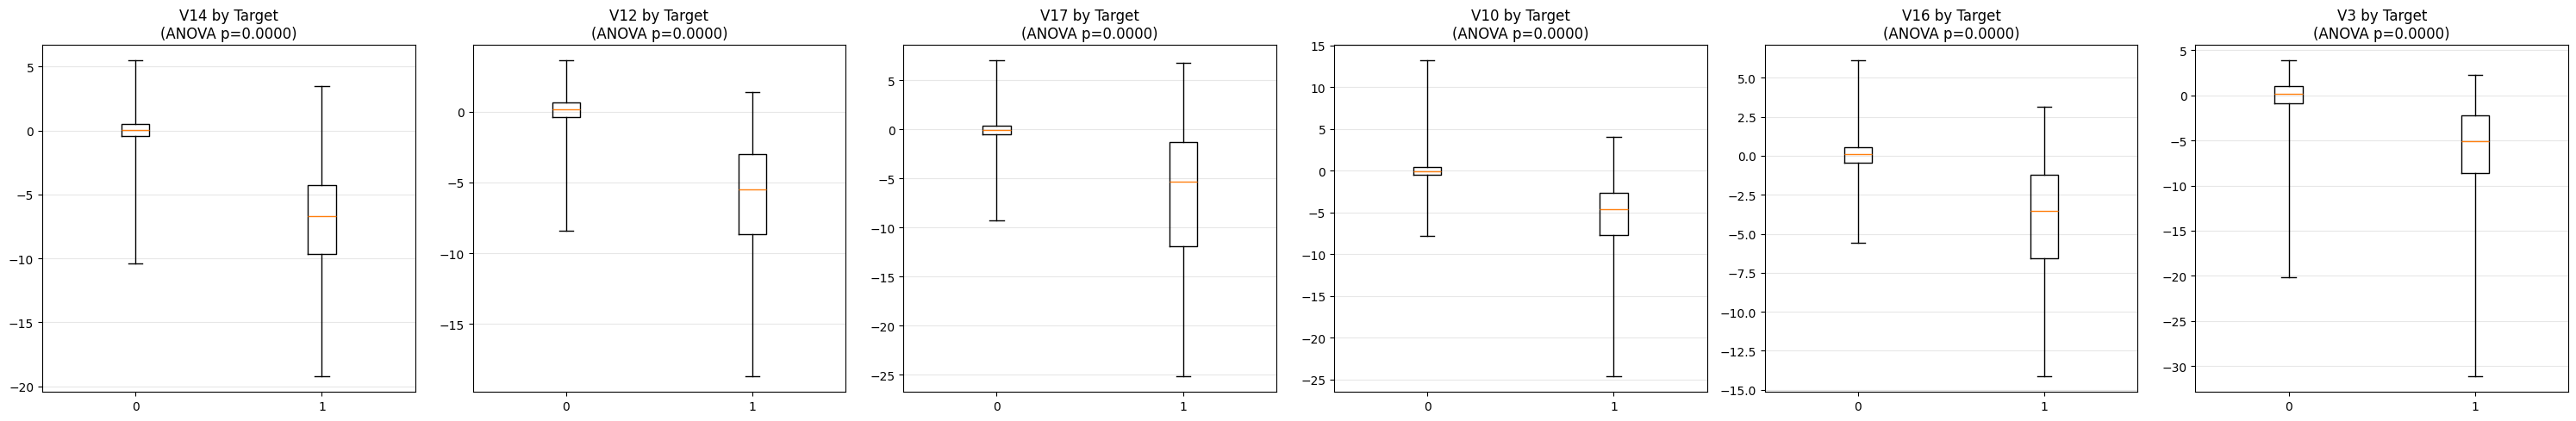

<Figure size 1000x1000 with 0 Axes>

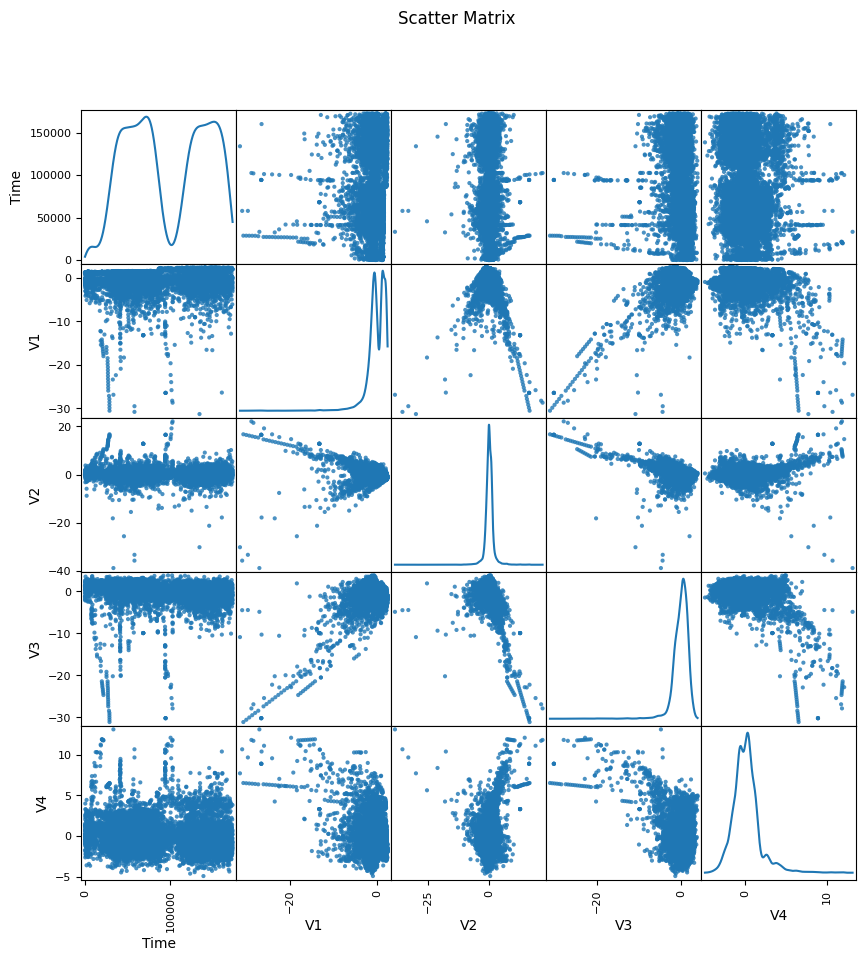

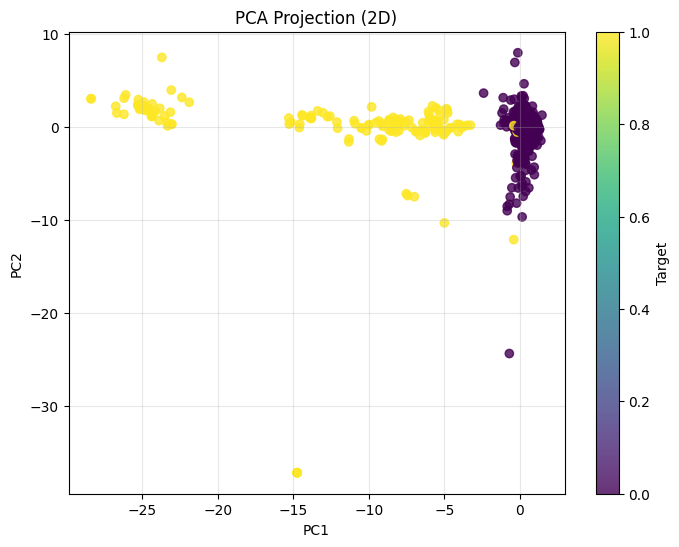

In [5]:
EDAVisualizer(profile, train).plot()

## 2. Data-quality gates

In [6]:
assert train.null_count().sum_horizontal().sum() == 0, "expected no nulls"
assert set(train["Class"].unique().to_list()) == {0, 1}, "Class must be binary"
print("Data-quality gates passed: no nulls, binary target.")

Data-quality gates passed: no nulls, binary target.


## 3. Baseline: class-weighted logistic regression (no resampling)

A useful baseline before reaching for resampling — `class_weight="balanced"`
alone, with no `Oversampling`/`Undersampling` step at all.

In [7]:
base_preprocessing = [
    {"name": "scale", "transformer": "StandardScaler", "params": {"columns": ["Time", "Amount"]}},
]

baseline_config = {
    "preprocessing": [
        {
            "name": "split",
            "transformer": "TrainTestSplitter",
            "params": {
                "test_size": 0.2,
                "random_state": 42,
                "stratify": True,
                "target_column": "Class",
            },
        },
        *base_preprocessing,
    ],
    "modeling": {
        "type": "logistic_regression",
        "params": {"max_iter": 2000, "class_weight": "balanced"},
    },
}

baseline_pipeline = SkyulfPipeline(baseline_config)
baseline_metrics = baseline_pipeline.fit(train, target_column="Class")

## 4. SMOTE oversampling vs. random undersampling

Both are fit on the training split only, so the test split's fraud rate
stays a faithful ~3.28% (this sample's own baseline) — never balanced
artificially at evaluation time.

In [8]:
smote_config = {
    "preprocessing": [
        {
            "name": "split",
            "transformer": "TrainTestSplitter",
            "params": {
                "test_size": 0.2,
                "random_state": 42,
                "stratify": True,
                "target_column": "Class",
            },
        },
        *base_preprocessing,
        {
            "name": "balance",
            "transformer": "Oversampling",
            "params": {
                "method": "smote",
                "target_column": "Class",
                "sampling_strategy": 0.5,
                "random_state": 42,
            },
        },
    ],
    "modeling": {
        "type": "random_forest_classifier",
        "params": {"n_estimators": 200, "random_state": 42},
    },
}

smote_pipeline = SkyulfPipeline(smote_config)
smote_metrics = smote_pipeline.fit(train, target_column="Class")

In [9]:
undersample_config = {
    "preprocessing": [
        {
            "name": "split",
            "transformer": "TrainTestSplitter",
            "params": {
                "test_size": 0.2,
                "random_state": 42,
                "stratify": True,
                "target_column": "Class",
            },
        },
        *base_preprocessing,
        {
            "name": "balance",
            "transformer": "Undersampling",
            "params": {
                "method": "random_under_sampling",
                "target_column": "Class",
                "sampling_strategy": 0.5,
                "random_state": 42,
            },
        },
    ],
    "modeling": {
        "type": "random_forest_classifier",
        "params": {"n_estimators": 200, "random_state": 42},
    },
}

undersample_pipeline = SkyulfPipeline(undersample_config)
undersample_metrics = undersample_pipeline.fit(train, target_column="Class")

## 5. Compare (PR-AUC first — the right metric for rare-event fraud detection)

In [10]:
def summarize(name, metrics):
    m = metrics["modeling"]
    report = m["splits"]["test"] if "splits" in m else m["test"]
    metrics_dict = report.metrics if hasattr(report, "metrics") else report
    pr_auc = metrics_dict.get("pr_auc")
    roc_auc = metrics_dict.get("roc_auc")
    precision = metrics_dict.get("precision")
    recall = metrics_dict.get("recall")
    f1 = metrics_dict.get("f1")
    print(
        f"{name:28s} pr_auc={pr_auc}  roc_auc={roc_auc}  precision={precision}  recall={recall}  f1={f1}"
    )


summarize("Baseline (class_weight only)", baseline_metrics)
summarize("SMOTE oversampling + RF", smote_metrics)
summarize("Random undersampling + RF", undersample_metrics)

Baseline (class_weight only) pr_auc=0.9459976724653684  roc_auc=0.9935384701967653  precision=0.6174496644295302  recall=0.9387755102040817  f1=0.7449392712550608
SMOTE oversampling + RF      pr_auc=0.94640955171091  roc_auc=0.9885437111763009  precision=0.9775280898876404  recall=0.8877551020408163  f1=0.93048128342246
Random undersampling + RF    pr_auc=0.9355092124285697  roc_auc=0.9908019050432996  precision=0.839622641509434  recall=0.9081632653061225  f1=0.8725490196078431


## Takeaways

- Accuracy is meaningless here — predicting "not fraud" for everyone scores
  ~96.7% accuracy in this sample (and ~99.83% on the real 0.17% data).
  **PR-AUC and recall/precision are the metrics that matter.**
- `Oversampling`/`Undersampling` (both fit only on the training split) let
  you trade off precision vs. recall differently than class-weighting alone
  — try both and pick based on the real business cost of a missed fraud vs.
  a false alarm.
- Remember: this sample's 3.28% positive rate is **enriched** from the real
  0.173% specifically so this notebook trains fast. Don't quote these exact
  metric values as representative of full-scale production performance —
  the *techniques* transfer, the *numbers* don't.